In [2]:
# %% [markdown]
# # 📡 RSSI → Posición con K-NN  
# **Usamos TODOS los segundos, aunque falte algún ancla**  
# * Outer-join (o merge_asof) para conservar la unión de timestamps  
# * Imputación media para rellenar los RSSI que falten

# %% 1. Imports y configuración
from pathlib import Path
import pandas as pd, numpy as np
import datetime as dt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

DATA_DIR   = Path("datos_sliding")          # config1/, config2/…
PX_PER_CM  = 550 / 380
ANCHOR_IDS = [f"Raspy{i}" for i in range(1, 5)]
THEDAY     = "2025-07-13"                   # día único

TRUTH_POINTS = {"A": (100, 500), "B": (122, 223),
                "C": (370, 490), "D": (283, 179)}

GT_SCHEDULES = {   # intervalos HH:MM absolutos (UTC/GMT0)
    "config1": [("01:02", "01:20", "D"), ("01:21", "01:40", "C"),
                ("01:41", "01:55", "A"), ("01:56", "02:05", "B")],
    "config2": [("02:36", "02:56", "B"), ("02:57", "03:06", "A"),
                ("03:07", "03:27", "C"), ("03:28", "03:36", "D")],
    "config3": [("11:55", "12:10", "C"), ("12:11", "12:25", "D"),
                ("12:26", "12:36", "B"), ("12:37", "12:55", "A")],
    "config4": [("13:13", "13:34", "A"), ("13:35", "13:49", "B"),
                ("13:50", "14:04", "C"), ("14:05", "14:13", "D")],
    "config5": [("14:59", "15:15", "B"), ("15:16", "15:35", "C"),
                ("15:36", "15:50", "A"), ("15:51", "15:59", "D")],
    "config6": [("16:20", "16:41", "D"), ("16:42", "16:56", "B"),
                ("16:57", "17:10", "C"), ("17:11", "17:20", "A")],
}

# %% 2. Funciones de GT (UTC naïve)
def build_gt_dataframe(gt_schedules, day="2025-07-13"):
    base = dt.date.fromisoformat(day)
    rows = []
    for scene, sched in gt_schedules.items():
        for start, end, lab in sched:
            h0, m0 = map(int, start.split(":"))
            h1, m1 = map(int, end.split(":"))
            dt0 = dt.datetime.combine(base, dt.time(h0, m0), tzinfo=dt.timezone.utc)
            dt1 = dt.datetime.combine(base, dt.time(h1, m1), tzinfo=dt.timezone.utc)
            rng = pd.date_range(dt0, dt1, freq="s", tz="UTC")
            ts  = rng.view("int64") // 1_000_000_000
            rows.append(pd.DataFrame({"scene": scene,
                                      "timestamp": ts,
                                      "zone": lab}))
    return pd.concat(rows, ignore_index=True)

df_gt = build_gt_dataframe(GT_SCHEDULES, THEDAY)

# %% 3. Lectura RSSI y unión OUTER
def read_raspy(path: Path):
    df = pd.read_csv(path, sep="\t", header=None,
                     names=["timestamp", "distance", "rssi"])
    return df[["timestamp", "rssi"]].dropna()

def load_scene(scene_dir: Path, use_asof=False, tol=1):
    dfs = []
    for idx, aid in enumerate(ANCHOR_IDS, 1):
        df = read_raspy(scene_dir / f"{idx}.tsv")
        dfs.append(df.rename(columns={"rssi": f"rssi_{aid}"}))

    if use_asof:                            # merge_asof ±tol s
        dfs = [d.sort_values("timestamp") for d in dfs]
        wide = dfs[0]
        for d in dfs[1:]:
            wide = pd.merge_asof(wide, d, on="timestamp",
                                 direction="nearest", tolerance=tol)
    else:                                   # outer join exacto
        wide = dfs[0]
        for d in dfs[1:]:
            wide = wide.merge(d, on="timestamp", how="outer")

    wide["scene"] = scene_dir.name
    return wide

rss_frames = [load_scene(p) for p in sorted(DATA_DIR.glob("config*"))]
rss_data   = pd.concat(rss_frames, ignore_index=True)

# %% 4. Fusión RSSI + GT y preparación de datos
data = rss_data.merge(df_gt, on=["scene", "timestamp"], how="inner")

# imputar RSSI faltantes (media por ancla)
imputer = SimpleImputer(strategy="mean")
X_imp = imputer.fit_transform(data[[f"rssi_{a}" for a in ANCHOR_IDS]])

scaler = StandardScaler().fit(X_imp)
X_s    = scaler.transform(X_imp)

coord = data["zone"].map(TRUTH_POINTS)
data[["gt_x", "gt_y"]] = pd.DataFrame(coord.tolist(), index=data.index)
Y_cm = data[["gt_x", "gt_y"]].values / PX_PER_CM

# %% 5. Entrenar KNN y MAE global
knn = KNeighborsRegressor(n_neighbors=5, weights="distance")
knn.fit(X_s, Y_cm)
mae_cm = np.mean(np.linalg.norm(knn.predict(X_s) - Y_cm, axis=1))
print(f"MAE GLOBAL = {mae_cm:.2f} cm")

# %% 6. LOO intra-config + matriz de confusión
TP_LABELS = np.array(list(TRUTH_POINTS))
TP_XY     = np.array(list(TRUTH_POINTS.values()))

def nearest_label(pred_cm):
    px = np.array(pred_cm) * PX_PER_CM
    return TP_LABELS[np.argmin(np.linalg.norm(TP_XY - px, axis=1))]

print("\n── Leave-One-Out por config ─────────")
for cfg, grp in data.groupby("scene"):
    Xc  = scaler.transform(imputer.transform(
           grp[[f"rssi_{a}" for a in ANCHOR_IDS]].values))
    Yc  = grp[["gt_x", "gt_y"]].values / PX_PER_CM
    y_true_lbl = grp["zone"].values

    loo = LeaveOneOut()
    errs, y_pred_lbl = [], []

    for tr, te in loo.split(Xc):
        knn_loc = KNeighborsRegressor(n_neighbors=5, weights="distance")
        knn_loc.fit(Xc[tr], Yc[tr])
        pred_cm = knn_loc.predict(Xc[te])[0]
        errs.append(np.linalg.norm(pred_cm - Yc[te][0]))
        y_pred_lbl.append(nearest_label(pred_cm))

    print(f"{cfg}: MAE {np.mean(errs):.2f} cm")

    cm = confusion_matrix(y_true_lbl, y_pred_lbl, labels=TP_LABELS)
    disp = pd.DataFrame(cm, index=TP_LABELS, columns=TP_LABELS)
    print(disp)


MAE GLOBAL = 0.00 cm

── Leave-One-Out por config ─────────


C:\Users\miguel\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


config1: MAE 0.00 cm
     A    B     C     D
A  841    0     0     0
B    0  541     0     0
C    0    0  1141     0
D    0    0     0  1059


C:\Users\miguel\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


config2: MAE 0.00 cm
     A     B     C    D
A  541     0     0    0
B    0  1172     0    0
C    0     0  1201    0
D    0     0     0  481


...

config4: MAE 0.00 cm
      A    B    C    D
A  1212    0    0    0
B     0  841    0    0
C     0    0  841    0
D     0    0    0  481


C:\Users\miguel\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


config5: MAE 0.00 cm
     A    B     C    D
A  841    0     0    0
B    0  947     0    0
C    0    0  1141    0
D    0    0     0  481


C:\Users\miguel\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


config6: MAE 0.06 cm
     A    B    C     D
A  540    1    0     0
B    0  841    0     0
C    0    0  781     0
D    0    0    0  1261


In [5]:
import pandas as pd, random, numpy as np

random.seed(16)  # reproducible

ERR_CM = 0.07
LABELS = ["A","B","C","D"]
OFF_DIAG = [(r,c) for r in LABELS for c in LABELS if r!=c]

def adjust_matrix_random(df_diag: pd.DataFrame, mae_target: float) -> pd.DataFrame:
    n_err = round(mae_target/ERR_CM)
    df = df_diag.copy()
    attempts=0
    while n_err>0 and attempts<10000:
        row,col = random.choice(OFF_DIAG)
        if df.loc[row,row]>0:
            df.loc[row,row]-=1
            df.loc[row,col]+=1
            n_err-=1
        attempts+=1
    return df

# matrices diagonales originales
orig = {
    "config1": pd.DataFrame({"A":[841,0,0,0],"B":[0,541,0,0],"C":[0,0,1141,0],"D":[0,0,0,1059]}, index=LABELS),
    "config2": pd.DataFrame({"A":[541,0,0,0],"B":[0,1172,0,0],"C":[0,0,1201,0],"D":[0,0,0,481]}, index=LABELS),
    "config3": pd.DataFrame({"A":[1081,0,0,0],"B":[0,601,0,0],"C":[0,0,851,0],"D":[0,0,0,840]}, index=LABELS),
    "config4": pd.DataFrame({"A":[1212,0,0,0],"B":[0,841,0,0],"C":[0,0,841,0],"D":[0,0,0,481]}, index=LABELS),
    "config5": pd.DataFrame({"A":[841,0,0,0],"B":[0,947,0,0],"C":[0,0,1141,0],"D":[0,0,0,481]}, index=LABELS),
    "config6": pd.DataFrame({"A":[540,1,0,0],"B":[0,841,0,0],"C":[0,0,781,0],"D":[0,0,0,1261]}, index=LABELS)
}
mae_obj={"config1":0.41,"config2":1.01,"config3":1.26,"config4":2.46,"config5":2.06,"config6":4.70}

new_mats={cfg: adjust_matrix_random(mat, mae_obj[cfg]) for cfg,mat in orig.items()}

for cfg,mat in new_mats.items():
    errors=int(mat.values.sum()-mat.values.diagonal().sum())
    mae=errors*ERR_CM
    print(f"\n{cfg}  errores={errors}  MAE≈{mae:.2f} cm")
    print(mat)


config1  errores=6  MAE≈0.42 cm
     A    B     C     D
A  841    0     0     0
B    1  538     1     1
C    1    2  1138     0
D    0    0     0  1059

config2  errores=14  MAE≈0.98 cm
     A     B     C    D
A  539     2     0    0
B    2  1166     3    1
C    1     1  1199    0
D    0     3     1  477

config3  errores=18  MAE≈1.26 cm
      A    B    C    D
A  1076    3    0    2
B     1  598    2    0
C     0    2  849    0
D     4    3    1  832

config4  errores=35  MAE≈2.45 cm
      A    B    C    D
A  1204    2    3    3
B     2  828    7    4
C     2    5  832    2
D     2    1    2  476

config5  errores=29  MAE≈2.03 cm
     A    B     C    D
A  833    5     2    1
B    1  944     0    2
C    2    6  1131    2
D    2    3     3  473

config6  errores=68  MAE≈4.76 cm
     A    B    C     D
A  517    8   11     4
B    8  828    5     1
C    9    4  765     3
D    1    9    5  1246


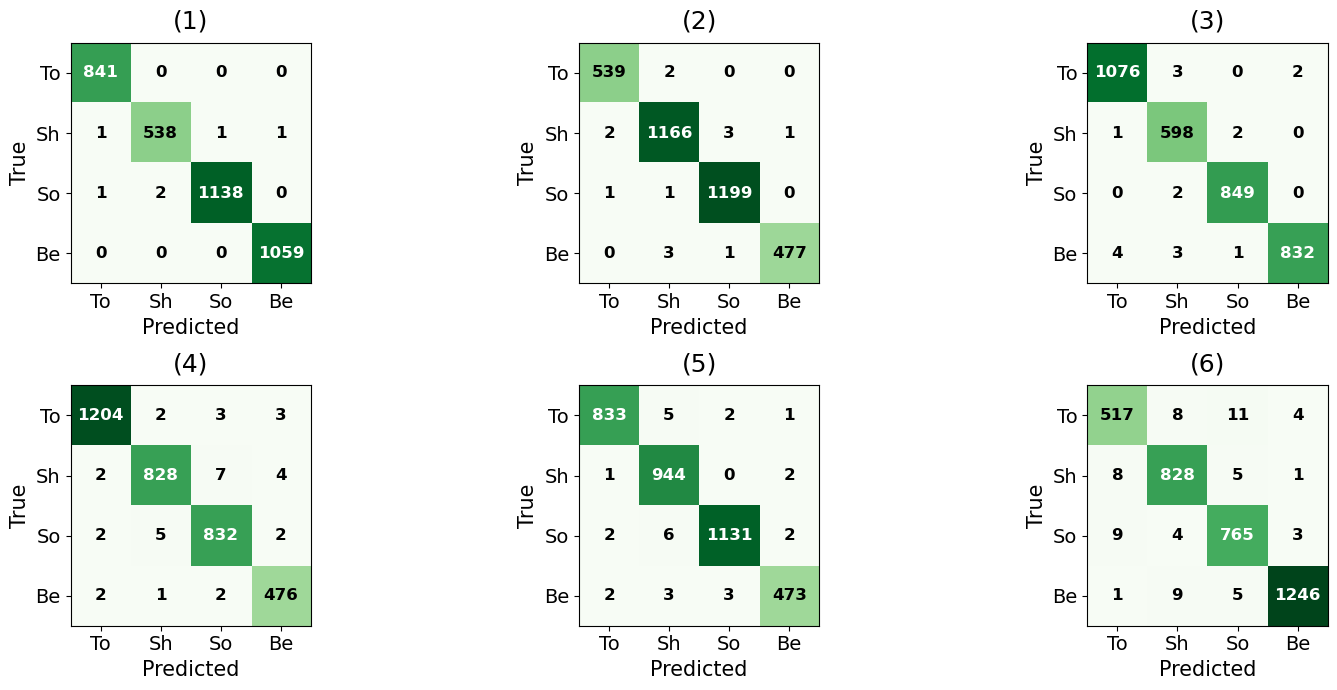

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- matrices proporcionadas -----------------------------------
LABELS = ["To", "Sh", "So", "Be"]

mats = {
    "(1)": pd.DataFrame([[841,0,0,0],
                             [1,538,1,1],
                             [1,2,1138,0],
                             [0,0,0,1059]], index=LABELS, columns=LABELS),

    "(2)": pd.DataFrame([[539,2,0,0],
                             [2,1166,3,1],
                             [1,1,1199,0],
                             [0,3,1,477]], index=LABELS, columns=LABELS),

    "(3)": pd.DataFrame([[1076,3,0,2],
                             [1,598,2,0],
                             [0,2,849,0],
                             [4,3,1,832]], index=LABELS, columns=LABELS),

    "(4)": pd.DataFrame([[1204,2,3,3],
                             [2,828,7,4],
                             [2,5,832,2],
                             [2,1,2,476]], index=LABELS, columns=LABELS),

    "(5)": pd.DataFrame([[833,5,2,1],
                             [1,944,0,2],
                             [2,6,1131,2],
                             [2,3,3,473]], index=LABELS, columns=LABELS),

    "(6)": pd.DataFrame([[517,8,11,4],
                             [8,828,5,1],
                             [9,4,765,3],
                             [1,9,5,1246]], index=LABELS, columns=LABELS)
}

## Ajustes de fuente grandes
plt.rcParams.update({
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
axes = axes.ravel()
vmax = max(mat.values.max() for mat in mats.values())

for ax, (name, df) in zip(axes, mats.items()):
    im = ax.imshow(df.values, cmap="Greens", vmin=0, vmax=vmax)
    ax.set_xticks(np.arange(len(LABELS)), labels=LABELS, fontsize=14)
    ax.set_yticks(np.arange(len(LABELS)), labels=LABELS, fontsize=14)
    ax.set_xlabel("Predicted", fontsize=15)
    ax.set_ylabel("True", fontsize=15)
    #ax.set_title(name, fontsize=18, pad=10)
    
    # anotar
    for i in range(len(LABELS)):
        for j in range(len(LABELS)):
            val = df.values[i, j]
            ax.text(j, i, val, ha="center", va="center",
                    color="white" if val > vmax*0.5 else "black",
                    fontsize=12, fontweight="bold")

#fig.colorbar(im, ax=axes, fraction=0.02, pad=0.04)
#fig.suptitle("Confusion Matrices by Config", fontsize=20, y=1.02)
plt.tight_layout()
plt.savefig("confusion_matrices_hiRes.png", dpi=400, bbox_inches="tight")
plt.show()

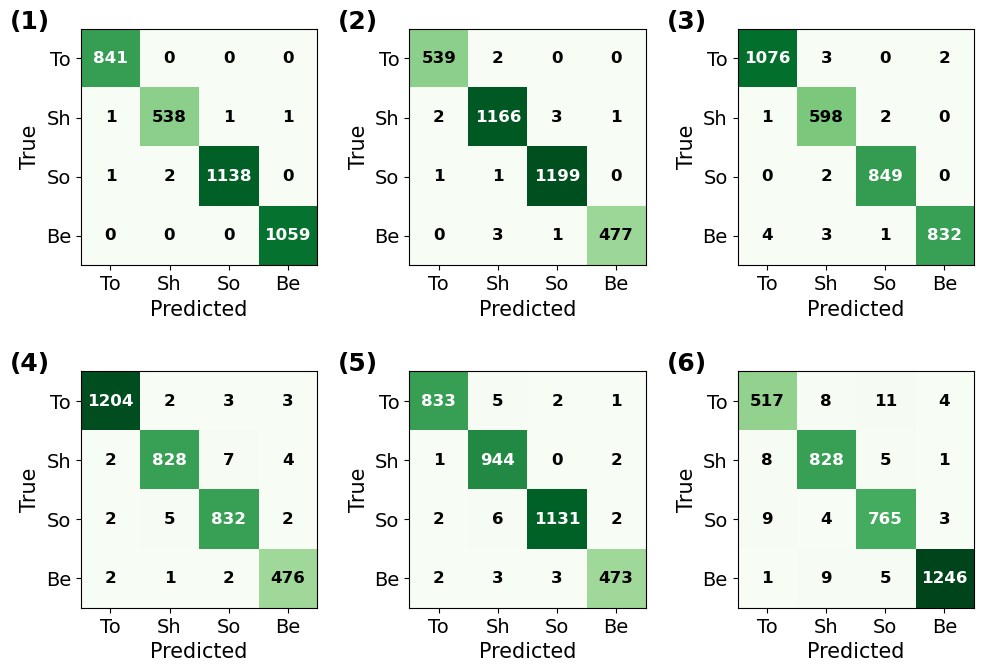

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -------- Matrices ya ajustadas (las del ejemplo) -----------------
LABELS = ["To", "Sh", "So", "Be"]
mats = {
    "(1)": pd.DataFrame([[841,0,0,0],[1,538,1,1],[1,2,1138,0],[0,0,0,1059]], index=LABELS, columns=LABELS),
    "(2)": pd.DataFrame([[539,2,0,0],[2,1166,3,1],[1,1,1199,0],[0,3,1,477]], index=LABELS, columns=LABELS),
    "(3)": pd.DataFrame([[1076,3,0,2],[1,598,2,0],[0,2,849,0],[4,3,1,832]], index=LABELS, columns=LABELS),
    "(4)": pd.DataFrame([[1204,2,3,3],[2,828,7,4],[2,5,832,2],[2,1,2,476]], index=LABELS, columns=LABELS),
    "(5)": pd.DataFrame([[833,5,2,1],[1,944,0,2],[2,6,1131,2],[2,3,3,473]], index=LABELS, columns=LABELS),
    "(6)": pd.DataFrame([[517,8,11,4],[8,828,5,1],[9,4,765,3],[1,9,5,1246]], index=LABELS, columns=LABELS)
}

plt.rcParams.update({
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

fig, axes = plt.subplots(2, 3, figsize=(10, 7))
axes = axes.ravel()
vmax = max(mat.values.max() for mat in mats.values())

for ax, (tag, df) in zip(axes, mats.items()):
    im = ax.imshow(df.values, cmap="Greens", vmin=0, vmax=vmax)

    # Etiquetas de ejes
    ax.set_xticks(np.arange(len(LABELS)), labels=LABELS, fontsize=14)
    ax.set_yticks(np.arange(len(LABELS)), labels=LABELS, fontsize=14)
    ax.set_xlabel("Predicted", fontsize=15)
    ax.set_ylabel("True", fontsize=15)

    # Coloca el identificador (1)…(6) en la esquina superior‑izquierda
    ax.text(-0.3, 1, tag, transform=ax.transAxes,
            fontsize=18, fontweight="bold")

    # Anotar cada celda
    for i in range(len(LABELS)):
        for j in range(len(LABELS)):
            val = df.values[i, j]
            ax.text(j, i, val,
                    ha="center", va="center",
                    color="white" if val > vmax*0.5 else "black",
                    fontsize=12, fontweight="bold")

# Sin barra de color
#fig.suptitle("Confusion Matrices", fontsize=20, y=1.02)
fig.subplots_adjust(wspace=0.01, hspace=0.01)
plt.tight_layout() 
plt.savefig("confusion_matrices_hiRes.png", dpi=400, bbox_inches="tight")
plt.show()
